# Build and evaluate models 



## read energy weather Germany data from saved csv file

In [3]:
import pandas as pd

df_energy_weather = pd.read_csv('../data/processed/energy_weather_2019_2025.csv', parse_dates=['DateUTC'])

#df_energy_weather.head()

## Train, test data split

* split into train and test sets based on date till end of 2024 for training, and 2025 for testing

In [4]:
train_data = df_energy_weather[df_energy_weather['DateUTC'] < '2025-01-01']
test_data = df_energy_weather[df_energy_weather['DateUTC'] >= '2025-01-01']

features_train = train_data.drop(['DateUTC', 'EnergyDemand'], axis=1)
target_train = train_data['EnergyDemand']
features_test = test_data.drop(['DateUTC', 'EnergyDemand'], axis=1)
target_test = test_data['EnergyDemand']

#print(f"Training data shape: {features_train.shape}")
#print(f"Testing data shape: {features_test.shape}")

# Build column transformer
* Standard Scaler for numerical columns: 
        'holiday_ratio', 'apparent_temperature', 'rain', 'snowfall', 'wind_speed_10m', 'shortwave_radiation',  'apparent_temperature_rolling_mean_24h', 'apparent_temperature_lag_24h', 'shortwave_radiation_0m_rolling_mean_24h',       'shortwave_radiation_0m_lag_24h', 'heating_degree', 'cooling_degree'
* OneHotEncoder for categorical columns: 'year', 'hour', 'weekday', 'month', 'is_weekend', 'is_holiday', 'is_pandemic_time'

In [ ]:
# column transformer pipeline for preprocessing
from sklearn.compose import ColumnTransformer   
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
# identify numeric and categorical columns
numeric_features = features_train.select_dtypes(include=['float64']).columns
categorical_features = features_train.select_dtypes(include=['int64']).columns
# numeric transformer
numeric_transformer = Pipeline(steps=[ 
    ('scaler', StandardScaler()) 
])  
# categorical transformer
categorical_transformer = Pipeline(steps=[  
    ('onehot', OneHotEncoder(handle_unknown='ignore')) 
])  

# combine transformers into a column transformer
preprocessor = ColumnTransformer(   
    transformers=[ 
        ('num', numeric_transformer, numeric_features), 
        ('cat', categorical_transformer, categorical_features) 
    ])

# Build basic models for ML
* Linear Regression
* Random Forest Regression
* Support Vector Regression - not suitable for such large number of data points
* XGBoost  

In [4]:
# Linear Regression pipeline
from sklearn.linear_model import LinearRegression   
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_pipeline = Pipeline(steps=[ 
    ('preprocessor', preprocessor), 
    ('model', LinearRegression()) 
])
lr_pipeline.fit(features_train, target_train)
lr_predictions = lr_pipeline.predict(features_test)
print("Linear Regression MAE:", mean_absolute_error(target_test, lr_predictions))
print("Linear Regression MSE:", mean_squared_error(target_test, lr_predictions))
print("Linear Regression R2:", r2_score(target_test, lr_predictions))


Linear Regression MAE: 2547.354449933479
Linear Regression MSE: 10482714.444310665
Linear Regression R2: 0.8688006751614057


In [67]:
# Random Forest model
from sklearn.ensemble import RandomForestRegressor  

rf_model = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
rf_model.fit(features_train, target_train)
rf_predictions = rf_model.predict(features_test) 
print("Random Forest MAE:", mean_absolute_error(target_test, rf_predictions))
print("Random Forest MSE:", mean_squared_error(target_test, rf_predictions))
print("Random Forest R2:", r2_score(target_test, rf_predictions))


Random Forest MAE: 1575.1080101979037
Random Forest MSE: 4517849.902686909
Random Forest R2: 0.9434555944356252


In [68]:
# Support Vector Regression pipeline for not suitable for large datasets, so we will just use a subset of the data for testing
features_train_subset = features_train.sample(n=10000, random_state=42)
target_train_subset = target_train.loc[features_train_subset.index]

from sklearn.svm import SVR

svr_pipeline = Pipeline(steps=[ 
    ('preprocessor', preprocessor), 
    ('model', SVR(kernel='rbf')) 
])
svr_pipeline.fit(features_train_subset, target_train_subset)
svr_predictions = svr_pipeline.predict(features_test)   
print("SVR MAE:", mean_absolute_error(target_test, svr_predictions))
print("SVR MSE:", mean_squared_error(target_test, svr_predictions))
print("SVR R2:", r2_score(target_test, svr_predictions))


SVR MAE: 7395.893166387707
SVR MSE: 79325527.43422136
SVR R2: 0.007179323912259616


In [ ]:
!pip install xgboost

In [69]:
# XGBoost model
from xgboost import XGBRegressor    

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(features_train, target_train)
xgb_predictions = xgb_model.predict(features_test)
print("XGBoost MAE:", mean_absolute_error(target_test, xgb_predictions))
print("XGBoost MSE:", mean_squared_error(target_test, xgb_predictions))
print("XGBoost R2:", r2_score(target_test, xgb_predictions))

XGBoost MAE: 1762.599139022436
XGBoost MSE: 5523347.023850575
XGBoost R2: 0.930871015877786


In [ ]:
!pip install lightgbm

In [14]:
# LightGBM model - tree based, no need for column transformer, can handle categorical features directly
from lightgbm import LGBMRegressor  
lgbm_model = LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, force_col_wise=True)
lgbm_model.fit(features_train, target_train)
lgbm_predictions = lgbm_model.predict(features_test)
print("LightGBM MAE:", mean_absolute_error(target_test, lgbm_predictions))
print("LightGBM MSE:", mean_squared_error(target_test, lgbm_predictions))
print("LightGBM R2:", r2_score(target_test, lgbm_predictions))

[LightGBM] [Info] Total Bins 4385
[LightGBM] [Info] Number of data points in the train set: 43848, number of used features: 25
[LightGBM] [Info] Start training from score 54632.045149
LightGBM MAE: 1671.340115660406
LightGBM MSE: 4743086.439371578
LightGBM R2: 0.9406365839876157


In [7]:
# suppress warnings for SARIMAX 
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

# SARIMAX model - time series model, can handle seasonality and exogenous variables (weather features)
target_train_sarimax = train_data.set_index('DateUTC')['EnergyDemand']
target_test_sarimax = test_data.set_index('DateUTC')['EnergyDemand']
features_train_sarimax = train_data.drop(['DateUTC', 'EnergyDemand'], axis=1).set_index(train_data['DateUTC'])
features_test_sarimax = test_data.drop(['DateUTC', 'EnergyDemand'], axis=1).set_index(test_data['DateUTC'])

# reduce data to daily frequency by resampling and taking the mean, since SARIMAX can be very slow on large datasets
target_train_sarimax = target_train_sarimax.resample('D').mean()
features_train_sarimax = features_train_sarimax.resample('D').mean()
target_test_sarimax = target_test_sarimax.resample('D').mean()
features_test_sarimax = features_test_sarimax.resample('D').mean()

from statsmodels.tsa.statespace.sarimax import SARIMAX

sarimax_model = SARIMAX(
    target_train_sarimax, 
    exog=features_train_sarimax, 
    order=(1, 0, 1), 
    seasonal_order=(1, 0, 1, 24))
sarimax_results = sarimax_model.fit(disp=False)

# use integer indices for predict to avoid date-matching issues with out-of-sample data
start_idx = len(target_train_sarimax)
end_idx = start_idx + len(target_test_sarimax) - 1
sarimax_predictions = sarimax_results.predict(start=start_idx, end=end_idx, exog=features_test_sarimax)
sarimax_predictions.index = target_test_sarimax.index  # restore date index for evaluation

print("SARIMAX MAE:", mean_absolute_error(target_test_sarimax, sarimax_predictions))
print("SARIMAX MSE:", mean_squared_error(target_test_sarimax, sarimax_predictions))
print("SARIMAX R2:", r2_score(target_test_sarimax, sarimax_predictions))


SARIMAX MAE: 470.5710113808074
SARIMAX MSE: 353320.79103916703
SARIMAX R2: 0.9916989358855567


# Tune the hyperparameters on selected models

* selected models: Random Forest, LightGBM 
* Use RandomizedSearchCV - samples fixed number of random combinations to reducing effort/time
* SARIMAX on daily data aggregation reached the best score

-  SARIMAX MAE: 470.5710113808074
-  SARIMAX MSE: 353320.79103916703
-  SARIMAX R2: 0.9916989358855567



In [10]:

# tune Random Forest hyperparameters using RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit

# use TimeSeriesSplit for cross-validation to respect the temporal order of the data
tscv = TimeSeriesSplit(n_splits=5)

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],          # lower depth = less overfitting
    'min_samples_split': [2, 5, 10], # min samples to split a node
    'min_samples_leaf': [1, 2, 4],   # min samples in a leaf
    'max_features': [1.0, 'sqrt', 'log2'], # 1.0 replaces deprecated 'auto' (use all features)
}
rf_random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42), 
    param_distributions=rf_param_grid, 
    n_iter=20, 
    cv=tscv, 
    scoring='neg_mean_absolute_error', #'neg_root_mean_squared_error get worse MAE and MSE, but better R2, so we will stick with MAE for tuning
    verbose=2, 
    random_state=42, 
    n_jobs=-1)
rf_random_search.fit(features_train, target_train)
best_rf_model = rf_random_search.best_estimator_  

print("Best Random Forest parameters:", rf_random_search.best_params_)
rf_tuned_predictions = best_rf_model.predict(features_test)
print("Tuned Random Forest MAE:", mean_absolute_error(target_test, rf_tuned_predictions))
print("Tuned Random Forest MSE:", mean_squared_error(target_test, rf_tuned_predictions))
print("Tuned Random Forest R2:", r2_score(target_test, rf_tuned_predictions))


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Random Forest parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': 5}
Tuned Random Forest MAE: 2026.0418047493247
Tuned Random Forest MSE: 7926521.660931342
Tuned Random Forest R2: 0.900793416079639


In [15]:
# tune LightGBM hyperparameters using RandomizedSearchCV
# use TimeSeriesSplit for cross-validation to respect the temporal order of the data
tscv = TimeSeriesSplit(n_splits=5)

lgbm_param_grid = { 
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 6, 9]
}   
lgbm_random_search = RandomizedSearchCV(
    estimator=LGBMRegressor(random_state=42, force_col_wise=True),   
    param_distributions=lgbm_param_grid,
    n_iter=10,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
    )
lgbm_random_search.fit(features_train, target_train)
best_lgbm_model = lgbm_random_search.best_estimator_    
print("Best LightGBM parameters:", lgbm_random_search.best_params_)
lgbm_tuned_predictions = best_lgbm_model.predict(features_test)
print("Tuned LightGBM MAE:", mean_absolute_error(target_test, lgbm_tuned_predictions))
print("Tuned LightGBM MSE:", mean_squared_error(target_test, lgbm_tuned_predictions))
print("Tuned LightGBM R2:", r2_score(target_test, lgbm_tuned_predictions))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[LightGBM] [Info] Total Bins 4385
[LightGBM] [Info] Number of data points in the train set: 43848, number of used features: 25
[LightGBM] [Info] Start training from score 54632.045149
Best LightGBM parameters: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1}
Tuned LightGBM MAE: 1728.1712985057413
Tuned LightGBM MSE: 5029289.12521093
Tuned LightGBM R2: 0.9370545347628089


In [ ]:
# save the best models for later use with pickle
import pickle   
with open('../models/best_rf_model.pkl', 'wb') as f:
    pickle.dump(best_rf_model, f)
with open('../models/best_lgbm_model.pkl', 'wb') as f:
    pickle.dump(best_lgbm_model, f)

# and LightGBM, Random Forest and XGBoost for comparison
with open('../models/lgbm_model.pkl', 'wb') as f:
    pickle.dump(lgbm_model, f)
with open('../models/rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
with open('../models/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

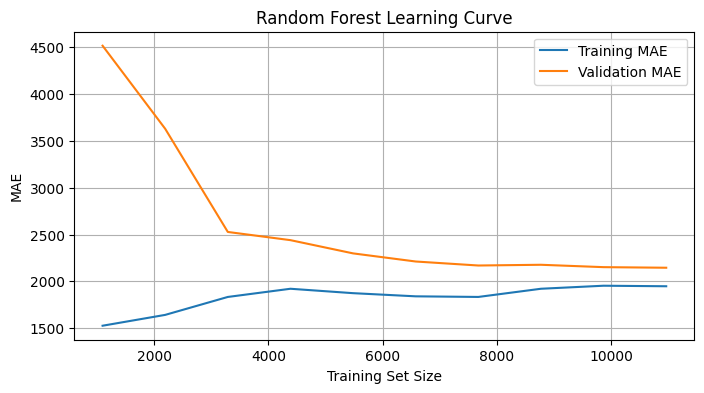

In [74]:
# learn curve for Random Forest to see how performance changes with more training data
from sklearn.model_selection import learning_curve
import numpy as np
from sklearn.model_selection import TimeSeriesSplit

# use TimeSeriesSplit for cross-validation to respect the temporal order of the data
tscv = TimeSeriesSplit(n_splits=3)

train_sizes, train_scores, test_scores = learning_curve(
    RandomForestRegressor(**rf_random_search.best_params_, random_state=42), 
    features_train, 
    target_train, 
    cv=tscv, 
    scoring='neg_mean_absolute_error', 
    n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10))
train_scores_mean = -np.mean(train_scores, axis=1)
test_scores_mean = -np.mean(test_scores, axis=1)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_sizes, train_scores_mean, label='Training MAE')
plt.plot(train_sizes, test_scores_mean, label='Validation MAE')
plt.xlabel('Training Set Size')
plt.ylabel('MAE')
plt.title('Random Forest Learning Curve')
plt.legend()
plt.grid()
plt.show()

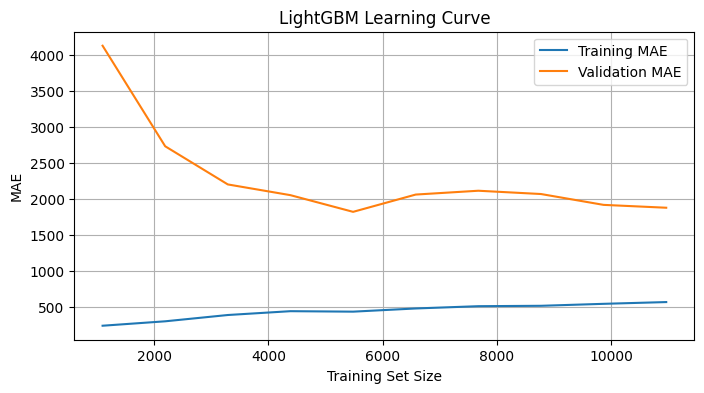

In [17]:
# learn curve for LightGBM to see how performance changes with more training data
from sklearn.model_selection import learning_curve
from lightgbm import LGBMRegressor 
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt

tscv = TimeSeriesSplit(n_splits=3)

train_sizes, train_scores, test_scores = learning_curve(
    LGBMRegressor(**lgbm_random_search.best_params_, random_state=42), 
    features_train, 
    target_train, 
    cv=tscv, 
    scoring='neg_mean_absolute_error', 
    n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10))
train_scores_mean = -np.mean(train_scores, axis=1)
test_scores_mean = -np.mean(test_scores, axis=1)    
plt.figure(figsize=(8, 4))
plt.plot(train_sizes, train_scores_mean, label='Training MAE')
plt.plot(train_sizes, test_scores_mean, label='Validation MAE')
plt.xlabel('Training Set Size')
plt.ylabel('MAE')
plt.title('LightGBM Learning Curve')    
plt.legend()
plt.grid()
plt.show()  


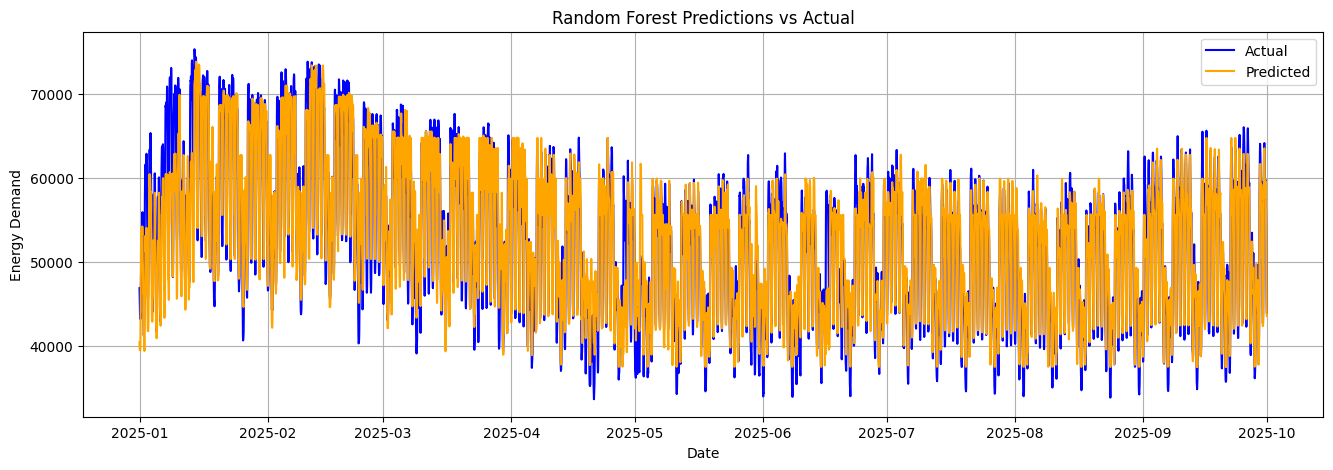

In [18]:
# plot the predictions vs actual values for the best random forest model
plt.figure(figsize=(16, 5)) 
plt.plot(test_data['DateUTC'], target_test, label='Actual', color='blue')
plt.plot(test_data['DateUTC'], rf_tuned_predictions, label='Predicted', color='orange')
plt.xlabel('Date')
plt.ylabel('Energy Demand')
plt.title('Random Forest Predictions vs Actual')  
plt.legend()
plt.grid()  
plt.show()


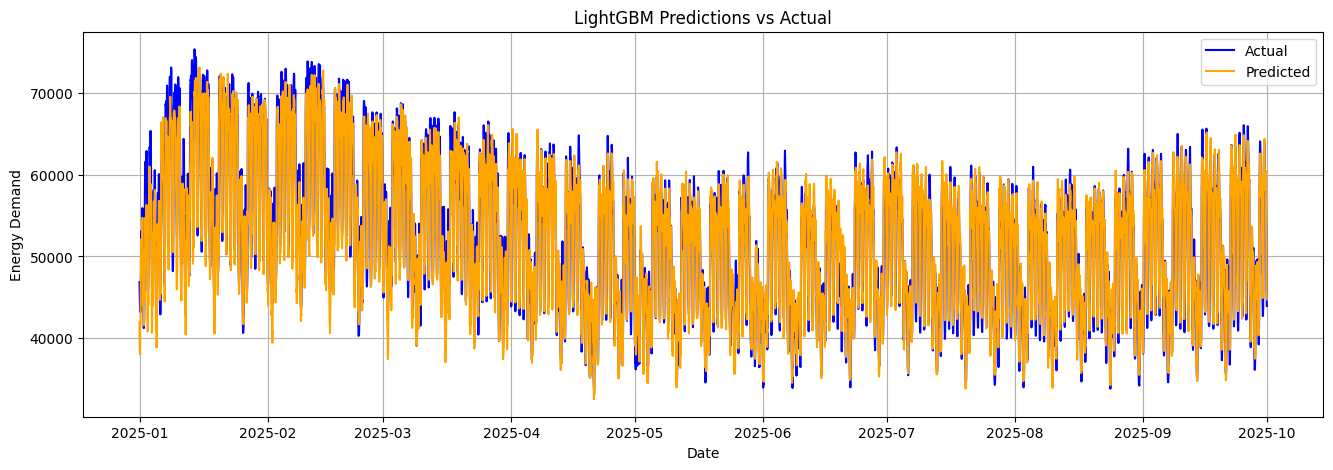

In [19]:
# plot the predictions vs actual values for the best LightGBM model
plt.figure(figsize=(16, 5)) 
plt.plot(test_data['DateUTC'], target_test, label='Actual', color='blue')
plt.plot(test_data['DateUTC'], lgbm_tuned_predictions, label='Predicted', color='orange')
plt.xlabel('Date')
plt.ylabel('Energy Demand')
plt.title('LightGBM Predictions vs Actual')
plt.legend()
plt.grid()
plt.show()